## Main Calculation
Checkpoint results are stored in `outputs/logs/` at regular intervals, `save_interval`.


In [3]:
import sys
sys.path.append('../src/pinn')
sys.path.append('../src/data_generation')


In [4]:
import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)


In [5]:
import jax
import jax.numpy as jnp

# Configure JAX to use only the CPU
# jax.config.update('jax_platform_name', 'cpu') 

print('jax:', jax.__version__)      # 0.7.2
print('devices:', jax.devices())    # [CudaDevice(id=0)]

import jax.experimental.layout as _layout
if not hasattr(_layout, 'DeviceLocalLayout'):
        # Provide a minimal alias so orbax can import function annotations\n",
        _layout.DeviceLocalLayout = _layout.Layout
        print('Patched jax.experimental.layout.DeviceLocalLayout ->', getattr(_layout, 'DeviceLocalLayout'))
import os
import numpy as np
import matplotlib.pyplot as plt
from pinn.train import create_train_state, train_step
from pinn.cryoet_io import load_mrc_data
import pickle
from flax.training import checkpoints
from pinn.utils import initial_loss
from tqdm.notebook import trange


jax: 0.7.2
devices: [CudaDevice(id=0)]
Patched jax.experimental.layout.DeviceLocalLayout -> <class 'jax._src.layout.Layout'>


In [6]:
# Utility function to convert GPU/JAX arrays to CPU/NumPy arrays

def to_numpy(tree):
    return jax.tree_util.tree_map(
        lambda x: np.asarray(jax.device_get(x)) if isinstance(x, (jnp.ndarray, np.ndarray)) else x,
        tree,
    )

def as_f32_scalar(x):
    # Make sure to extract as a scalar (float32) even if it's an array/DeviceArray
    return np.asarray(x, dtype=np.float32).reshape(()).item()

In [7]:
GRID_SIZE = 64                  # cryo-ET data will be resampled to GRID_SIZE^3 (64 * 64 * 64)
NUM_CHECKPOINTS_TO_KEEP = 1000  # Checkpoint retention count (older ones get removed)

# Parameters
lambda_1 = 1000000       # Weight for boundary loss (data loss)
lambda_2 = 50            # Weight for physics loss
shape = "bud_04"
sdf_pretrain="plane"   # sphere or plane
flip_ratio=0.15
missing_ratio=0.7
# wedge_axis='z'
num_collocation = 10000
num_steps = 10000  # 10000
save_interval = 100
threshold = 0.8
learning_rate = 1e-3  #1e-3
radius = 0.4

# Load initial checkpoint data
# init_ckpt_dir= os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_0")
# init_ckpt_dir= os.path.abspath(f"../outputs/logs/{shape}/test")
# init_ckpt_path = os.path.join(init_ckpt_dir, f"checkpoint_{num_steps}")
# init_ckpt = checkpoints.restore_checkpoint(ckpt_dir=init_ckpt_path, target=None)

# Initialize JAX random key
key = jax.random.PRNGKey(0)

# Create train state
state, model = create_train_state(key, lambda_1=lambda_1, lambda_2=lambda_2, threshold = threshold, sdf_pretrain=sdf_pretrain, learning_rate=learning_rate, radius=radius)
# state, model = create_train_state(key, lambda_1=lambda_1, lambda_2=lambda_2, threshold = threshold, init_ckpt=init_ckpt, learning_rate=learning_rate, radius=radius)
print(f"Using lambda_1: {state.lambda_1}, lambda_2: {state.lambda_2}, threshold: {state.threshold}")

### LOAD MRC DATA #####
# mrc_file_path = f"../data/synthetic/{shape}.mrc"
# mrc_file_path = f"../data/experimental/downsampled/{shape}.mrc"
# mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}.mrc"
# mrc_file_path = f"../data/synthetic/additive/{shape}_f{str(flip_ratio).replace('.', '')}.mrc"
mrc_file_path = f"../data/synthetic/combine/{shape}_a{str(flip_ratio).replace('.', '')}_m{str(missing_ratio).replace('.', '')}.mrc"
# mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}_w{wedge_axis}.mrc"
# mrc_file_path = f"../data/synthetic/hetero/{shape}_h{hetero_scale}.mrc"

cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)
print("MRC data loaded successfully! Shape:", cryoET_data.shape)
print("Cryo-ET Data Shape:", cryoET_data.shape)
print("Cryo-ET Data Min:", cryoET_data.min())
print("Cryo-ET Data Max:", cryoET_data.max())
print("Cryo-ET Unique Values:", jnp.unique(cryoET_data))


x_train = (jax.random.uniform(key, (num_collocation, 3), minval=-1, maxval=1)) # Sampled from [-1, 1]^3
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}")

# --- keep the same schema for step 0 ---
init_d = initial_loss(state, x_train, cryoET_data)     # Get the dictionary of initial losses
init_total = init_d.get("total_loss", init_d.get("total", init_d.get("loss", 0.0)))
init_data  = init_d.get("data_loss",  init_d.get("data",  0.0))
init_phys  = init_d.get("physics_loss", init_d.get("phys", init_d.get("physics", 0.0)))

payload0 = {
    "state": to_numpy(state),
    "loss": {
        "step":         np.asarray([0], dtype=np.int64),
        "total_loss":   np.asarray([as_f32_scalar(init_total)], dtype=np.float32),
        "data_loss":    np.asarray([as_f32_scalar(init_data)],  dtype=np.float32),
        "physics_loss": np.asarray([as_f32_scalar(init_phys)],  dtype=np.float32),
    }
}

checkpoints.save_checkpoint(
    ckpt_dir=checkpoint_dir,
    target=payload0,
    step=0,
    overwrite=False,
    keep=NUM_CHECKPOINTS_TO_KEEP,
)

loss_history = []

# for step in range(num_steps):
for step in trange(num_steps):
    state, loss_val, loss_data_val, loss_physics_val = train_step(state, x_train, cryoET_data)

    loss_history.append({
    "step":  step + 1,
    "total_loss":   loss_val,
    "data_loss":    loss_data_val,
    "physics_loss": loss_physics_val
    })

    if (step + 1) % save_interval == 0:
        batched_loss = {
          "step":         np.asarray([e["step"] for e in loss_history], dtype=np.int64),
        "total_loss":   np.asarray([as_f32_scalar(e["total_loss"])   for e in loss_history], dtype=np.float32),
        "data_loss":    np.asarray([as_f32_scalar(e["data_loss"])    for e in loss_history], dtype=np.float32),
        "physics_loss": np.asarray([as_f32_scalar(e["physics_loss"]) for e in loss_history], dtype=np.float32),
        }

        payload = {
            "state": to_numpy(state),  # 항상 CPU NumPy로
            "loss":  batched_loss
        }

        checkpoints.save_checkpoint(
            ckpt_dir=checkpoint_dir,
            target=payload,
            step=step + 1,
            overwrite=False,
            keep=NUM_CHECKPOINTS_TO_KEEP,
        )
        # print(f"Checkpoint saved at step {step+1}")
        loss_history = []


Pretraining the network using SDF...
Using lambda_1: 1000000, lambda_2: 50, threshold: 0.8
MRC data loaded successfully! Shape: (64, 64, 64)
Cryo-ET Data Shape: (64, 64, 64)
Cryo-ET Data Min: 0.105025835
Cryo-ET Data Max: 0.95442456
Cryo-ET Unique Values: [0.10502584 0.13638075 0.1511317  ... 0.94397515 0.9532471  0.95442456]


  0%|          | 0/10000 [00:00<?, ?it/s]

### Analysis

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/bud_04/lambda_1000000_50


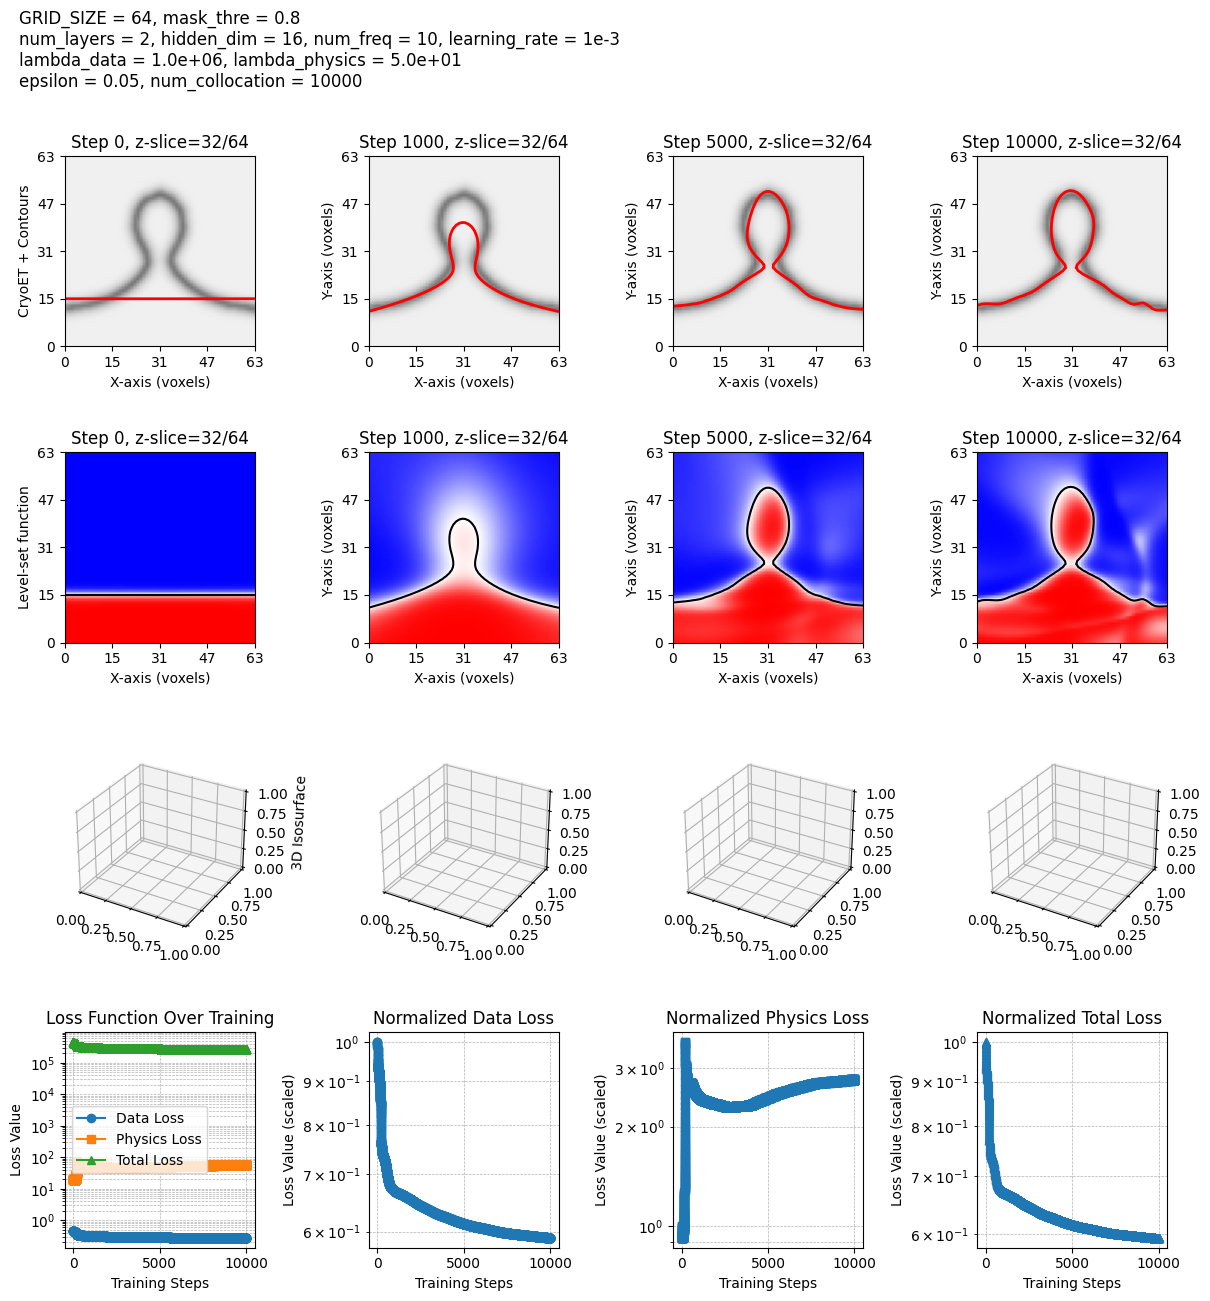

In [8]:
## make one combined image file

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_result,
    visualize_cryoET_with_contours,
    plot_3d_isosurface,
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
)
from pinn.utils import assemble_loss_history

GRID_SIZE = 64
# lambda_1 = 1000000
# lambda_2 = 50
num_collocation = 10000
num_layers = 2
# shape = "multi"

# steps_to_visualize = [0, 100, 1000, 10000]
steps_to_visualize = [0, 1000, 5000, 10000]
steps_series = list(range(0, 10001, 100))

# steps_to_visualize = [0, 5000, 10000, 20000]
# steps_series = list(range(0, 20001, 100))

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}")
# checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/data_1016/f015/lambda_{lambda_1}_{lambda_2}")
print(checkpoint_dir)
checkpoint_data = {}
for step in steps_series:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    # print(checkpoint_path)
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load CryoET data
mrc_file_path = f"../data/synthetic/{shape}.mrc"
# mrc_file_path = f"../data/experimental/downsampled/{shape}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

# Create a big figure with 4 rows: cryoET + contours, prediction result, 3D isosurface, and leave room for loss plots
fig = plt.figure(figsize=(3*4, 12))

# Row 1: visualize_cryoET_with_contours
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, i + 1)
    visualize_cryoET_with_contours(ax, step, checkpoint_data[step], cryoET_data, grid_size=GRID_SIZE, slice_index=GRID_SIZE//2, axis="z")
    # visualize_cryoET_with_contours(ax, step, checkpoint_data[step], cryoET_data, grid_size=GRID_SIZE, slice_index=36, axis="y")    
    if i == 0:
        ax.set_ylabel("CryoET + Contours")

# Row 2: visualize_checkpoint_result
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 4 + i + 1)
    visualize_checkpoint_result(ax, step, checkpoint_data[step], grid_size=GRID_SIZE, slice_index=GRID_SIZE//2, axis="z")
    # visualize_checkpoint_result(ax, step, checkpoint_data[step], grid_size=GRID_SIZE, slice_index=36, axis="y")
    if i == 0:
        ax.set_ylabel("Level-set function")

# Row 3: plot_3d_isosurface
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 8 + i + 1, projection='3d')
    # plot_3d_isosurface(ax, step, checkpoint_data[step], grid_size=GRID_SIZE)
    if i == 0:
        ax.set_zlabel("3D Isosurface", rotation=180)

# Row 4: loss history
assembled_loss = assemble_loss_history(checkpoint_data)
ax = fig.add_subplot(4, 4, 12+1)
plot_loss_history_ax(ax, assembled_loss)
for i in [0,1,2]:
    ax = fig.add_subplot(4, 4, 12+i+2)
    plot_normalized_loss_history_ax(ax, i, assembled_loss)
    

info_text = (
    f"GRID_SIZE = {GRID_SIZE}, mask_thre = 0.8\n"
    f"num_layers = {num_layers}, hidden_dim = 16, num_freq = 10, learning_rate = 1e-3\n"
    f"lambda_data = {lambda_1:.1e}, lambda_physics = {lambda_2:.1e}\n"
    f"epsilon = 0.05, num_collocation = {num_collocation}"
)

fig.text(
    0.02, 1.08,  # (x, y) position in figure coordinates
    info_text,
    fontsize=12,
    ha='left',
    va='top'
)

plt.tight_layout()
# plt.savefig("../outputs/figs/analysis.png", dpi=300, bbox_inches="tight")
plt.show()

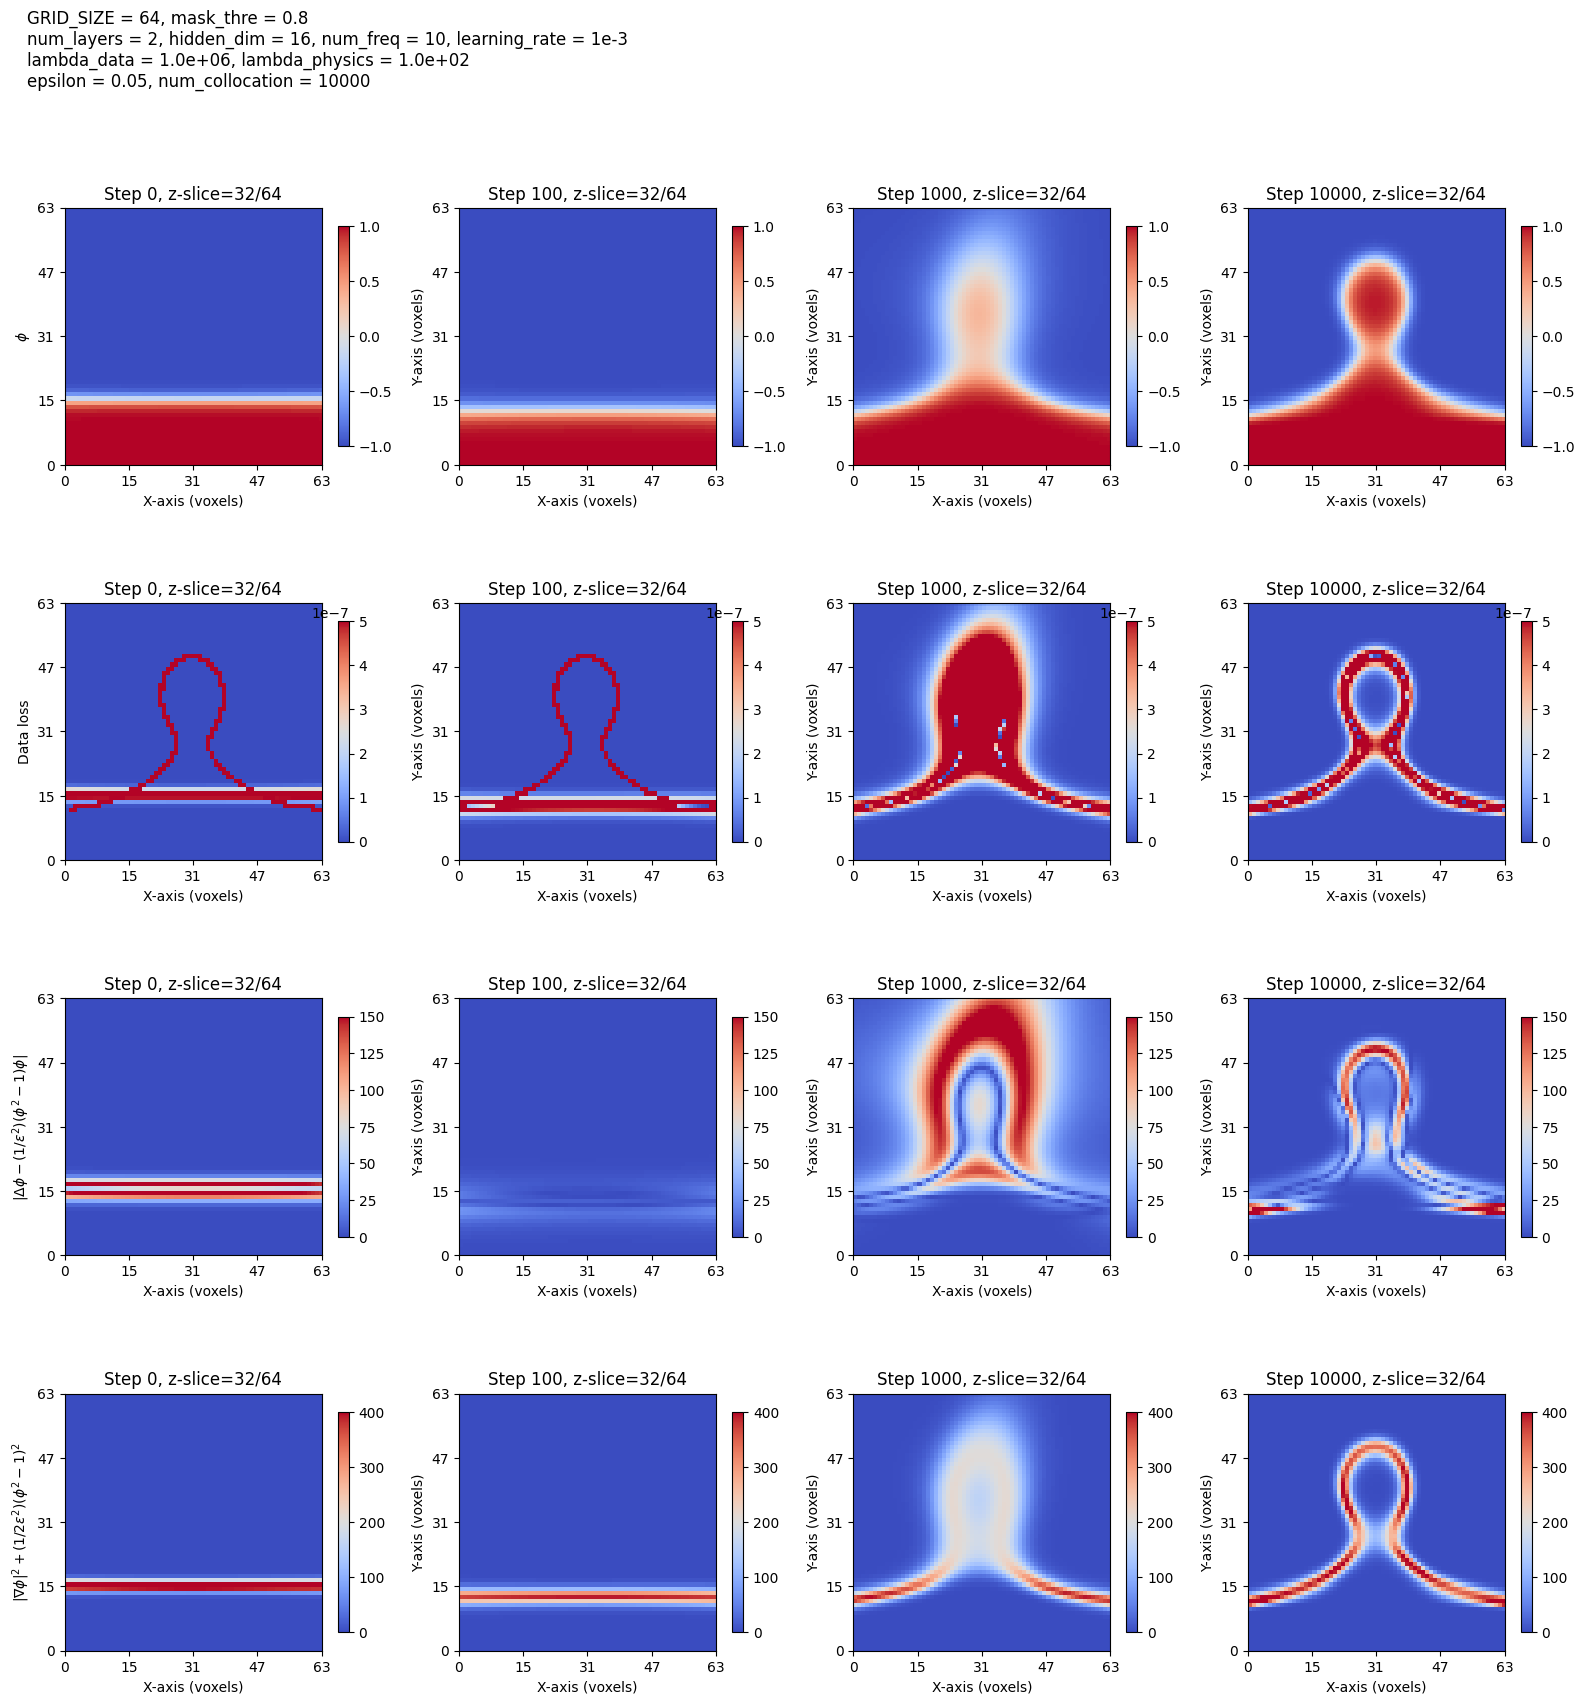

In [8]:
## make one combined physics analysis image

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_result,
    visualize_physics_loss,
)
from pinn.utils import assemble_loss_history

GRID_SIZE = 64
# lambda_1 = 5000000
# lambda_2 = 1
num_collocation = 10000
num_layers = 2
epsilon = 0.05
# shape = "multi"

# steps_to_visualize = [0, 200, 600, 1000]
# steps_to_visualize = [0, 2000, 6000, 10000]
# steps_to_visualize = [0, 1000, 6000, 10000]
steps_to_visualize = [0, 100, 1000, 10000]
# steps_to_visualize = [0, 10000, 20000, 30000]
# steps_to_visualize = [0, 30000, 60000, 90000]

# Load checkpoint data
# checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}")
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/data_1203/clean/lambda_{lambda_1}_{lambda_2}")
checkpoint_data = {}
for step in steps_to_visualize:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load CryoET data
mrc_file_path = f"../data/synthetic/{shape}.mrc"
# mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}.mrc"
# mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}_w{wedge_axis}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)


# Create a big figure with 4 rows: cryoET + contours, prediction result, 3D isosurface, and leave room for loss plots
fig = plt.figure(figsize=(4*4, 4*4))


# Row 1: Phi
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="phi",
                           grid_size=GRID_SIZE, slice_index=32, axis="z", vmin=-1, vmax=1)
    # visualize_checkpoint_result(ax, step, checkpoint_data[step], grid_size=GRID_SIZE, slice_index=32, axis="z", colorbar = True)
    if i == 0:
        ax.set_ylabel(r"$\phi$")

# Row 2: data loss
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 4 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="data",
                           grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", vmin=0, vmax=5e-7, cryoET_data=cryoET_data)
    if i == 0:
        ax.set_ylabel(r"Data loss")

# Row 3: physics loss
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 8 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="residual",
                           grid_size=GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=150)

    if i == 0:
        ax.set_ylabel(r"$|\Delta \phi - (1/\epsilon^2)(\phi^2 - 1)\phi|$")

# Row 4: tension energy
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 12 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="tension",
                           grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", vmin=0, vmax=400)
    if i == 0:
        ax.set_ylabel(r"$|\nabla \phi|^2 + (1/2\epsilon^2) (\phi^2 -1)^2$")
        # ax.set_ylabel(r"$|\nabla\phi|^2$")


info_text = (
    f"GRID_SIZE = {GRID_SIZE}, mask_thre = 0.8\n"
    f"num_layers = {num_layers}, hidden_dim = 16, num_freq = 10, learning_rate = 1e-3\n"
    f"lambda_data = {lambda_1:.1e}, lambda_physics = {lambda_2:.1e}\n"
    f"epsilon = {epsilon}, num_collocation = {num_collocation}"
)

fig.text(
    0.02, 1.08,  # (x, y) position in figure coordinates
    info_text,
    fontsize=12,
    ha='left',
    va='top'
)

plt.tight_layout()
# plt.savefig("../outputs/figs/physics.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
# Make a movie

import matplotlib.pyplot as plt
import os
from pinn.plot import plot_3d_isosurface
from flax.training import checkpoints
import imageio
import re

lambda_1 = 1000000
lambda_2 = 0
shape = "bud_04"
flip_ratio=0.15
# wedge_axis='z'
version = "0926/plane"
str_flip = str(flip_ratio).replace('.', '')


steps_to_visualize = list(range(0, 3001, 100))
log_dir = os.path.abspath(f"../outputs/logs/{shape}/data_{version}/f{str_flip}/lambda_{lambda_1}_{lambda_2}/")
frame_dir = os.path.join(log_dir, f"3d_iso")

def save_isosurface_frame(step, checkpoint, save_dir="frames", grid_size=64):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    plot_3d_isosurface(ax, step, checkpoint, grid_size)
    
    os.makedirs(save_dir, exist_ok=True)
    filename = os.path.join(save_dir, f"frame_{step:06d}.png")
    plt.savefig(filename, dpi=150)
    plt.close(fig)

def make_movie_from_frames(frame_dir="frames", output="movie.mp4", fps=12, start=0, end=30000):
    # Match files like frame_XXXX.png and extract the numeric part
    pattern = re.compile(r"frame_(\d+)\.png")

    frames = []
    for fname in os.listdir(frame_dir):
        match = pattern.match(fname)
        if match:
            index = int(match.group(1))
            if start <= index <= end:
                frames.append((index, os.path.join(frame_dir, fname)))

    frames.sort(key=lambda x: x[0])

    with imageio.get_writer(output, fps=fps) as writer:
        for _, frame_path in frames:
            image = imageio.imread(frame_path)
            writer.append_data(image)

for step in steps_to_visualize:
    ckpt_path = os.path.join(log_dir, f"checkpoint_{step}")
    ckpt_data = checkpoints.restore_checkpoint(ckpt_dir=ckpt_path, target=None)
    print(f"saving step {step}")
    save_isosurface_frame(step, ckpt_data, save_dir=frame_dir)

output=os.path.abspath(f"{frame_dir}/movie.mp4")
make_movie_from_frames(frame_dir=frame_dir, output=output)

saving step 0
saving step 100
saving step 200
saving step 300
saving step 400
saving step 500
saving step 600
saving step 700
saving step 800
saving step 900
saving step 1000
saving step 1100
saving step 1200
saving step 1300
saving step 1400
saving step 1500
saving step 1600
saving step 1700
saving step 1800
saving step 1900
saving step 2000
saving step 2100
saving step 2200
saving step 2300
saving step 2400
saving step 2500
saving step 2600
saving step 2700
saving step 2800
saving step 2900
saving step 3000


/tmp/ipykernel_40035/3169113993.py:49: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(frame_path)


In [13]:
import sys
sys.path.append('../src/pinn')
sys.path.append('../src/data_generation')

# %run routine.py
%run routine_noise.py

jax: 0.7.2
devices: [CudaDevice(id=0)]
Input file: ../data/synthetic/combine/biconcave_a02_m09.mrc
MRC data loaded successfully! Shape: (64, 64, 64)
Cryo-ET Data Shape: (64, 64, 64)
Cryo-ET Data Min: 0.11842526
Cryo-ET Data Max: 0.97564065
Cryo-ET Unique Values: [0.11842526 0.18286084 0.21277623 ... 0.9732468  0.97443885 0.97564065]
Pretraining the network using SDF...
Using lambda_1: 1000000, lambda_2: 0


  0%|          | 0/10000 [00:00<?, ?it/s]

Pretraining the network using SDF...
Using lambda_1: 1000000, lambda_2: 50


  0%|          | 0/10000 [00:00<?, ?it/s]

Input file: ../data/synthetic/combine/bud_04_a02_m09.mrc
MRC data loaded successfully! Shape: (64, 64, 64)
Cryo-ET Data Shape: (64, 64, 64)
Cryo-ET Data Min: 0.14251643
Cryo-ET Data Max: 0.98026
Cryo-ET Unique Values: [0.14251643 0.18329656 0.20757109 ... 0.9723536  0.9742936  0.98026   ]
Pretraining the network using SDF...
Using lambda_1: 1000000, lambda_2: 0


...

  0%|          | 0/10000 [00:00<?, ?it/s]

Input file: ../data/synthetic/combine/multi_a02_m09.mrc
MRC data loaded successfully! Shape: (64, 64, 64)
Cryo-ET Data Shape: (64, 64, 64)
Cryo-ET Data Min: 0.14867686
Cryo-ET Data Max: 0.9790939
Cryo-ET Unique Values: [0.14867686 0.17807192 0.1867157  ... 0.97235537 0.9742618  0.9790939 ]
Pretraining the network using SDF...
Using lambda_1: 1000000, lambda_2: 0


  0%|          | 0/10000 [00:00<?, ?it/s]

Pretraining the network using SDF...
Using lambda_1: 1000000, lambda_2: 50


  0%|          | 0/10000 [00:00<?, ?it/s]